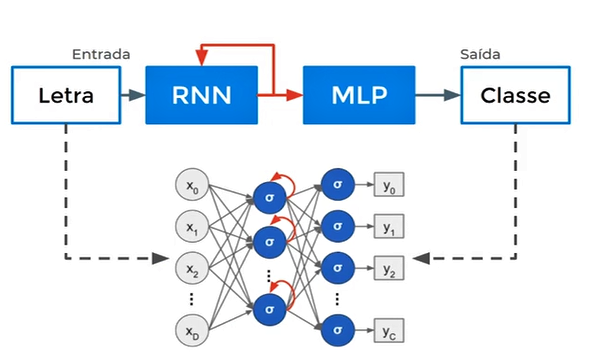

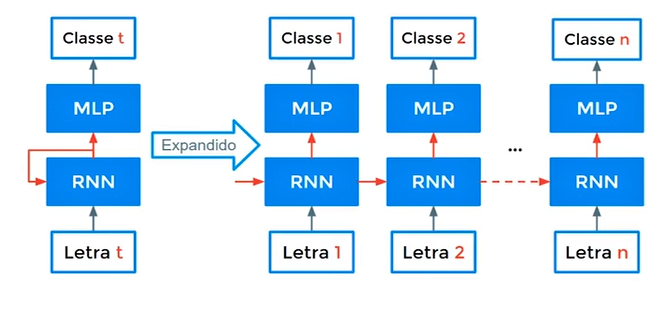

In [13]:
import os
import unicodedata
import numpy as np
import torch
import string
from torch import nn
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter

In [14]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip

--2025-03-31 20:05:22--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 18.165.116.45, 18.165.116.121, 18.165.116.36, ...
Connecting to download.pytorch.org (download.pytorch.org)|18.165.116.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip.1’

data.zip.1          100%[===================>]   2.75M  --.-KB/s    in 0.08s   

2025-03-31 20:05:22 (34.8 MB/s) - ‘data.zip.1’ saved [2882130/2882130]

Archive:  data.zip
replace data/eng-fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data/eng-fra.txt        
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    

In [15]:
root = './data/names'
arqs = sorted(os.listdir(root))
arqs

['Arabic.txt',
 'Chinese.txt',
 'Czech.txt',
 'Dutch.txt',
 'English.txt',
 'French.txt',
 'German.txt',
 'Greek.txt',
 'Irish.txt',
 'Italian.txt',
 'Japanese.txt',
 'Korean.txt',
 'Polish.txt',
 'Portuguese.txt',
 'Russian.txt',
 'Scottish.txt',
 'Spanish.txt',
 'Vietnamese.txt']

In [16]:
def le_arquivos(path):
  nomes = open(path).read().split('\n')
  nome = [unicodedata.normalize('NFKD', nome).encode('ascii', 'ignore') for nome in nomes]
  categoria = path.split('/')[-1].split('.')[0]
  rotulos = np.repeat(categoria, len(nomes))
  return nomes, rotulos

categorias = [a[:-4] for a in arqs]
dados, rotulos = [], []
samples_perclass = []

for arq in arqs:
  retorno = le_arquivos(os.path.join(root,arq))
  dados.append(retorno[0])
  rotulos.append(retorno[1])

  samples_perclass.append( (arq, len(retorno[0])) )

len(dados), len(rotulos)

(18, 18)

In [17]:
dados[0][0:10]

['Khoury',
 'Nahas',
 'Daher',
 'Gerges',
 'Nazari',
 'Maalouf',
 'Gerges',
 'Naifeh',
 'Guirguis',
 'Baba']

In [18]:
len(dados[0]), len(rotulos[0])

(2001, 2001)

In [19]:
#exemplo
nome_ex = "Clóvis"
nome_ex = unicodedata.normalize('NFKD', nome_ex).encode('ascii', 'ignore')
nome_ex

b'Clovis'

In [20]:
dicionario = string.ascii_letters + " '-"
dicionario

"abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ '-"

In [21]:
def name2tensor(name):
    name_tns = torch.zeros(len(name), len(dicionario))
    for k, letra in enumerate(name):
        if letra in dicionario:
            name_tns[k][dicionario.index(letra)] = 1
        else:
            pass
    return name_tns


print(dicionario)
dados[0][10], name2tensor(dados[0][10])

abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ '-


('Sabbagh',
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.,

In [22]:
dados

[['Khoury',
  'Nahas',
  'Daher',
  'Gerges',
  'Nazari',
  'Maalouf',
  'Gerges',
  'Naifeh',
  'Guirguis',
  'Baba',
  'Sabbagh',
  'Attia',
  'Tahan',
  'Haddad',
  'Aswad',
  'Najjar',
  'Dagher',
  'Maloof',
  'Isa',
  'Asghar',
  'Nader',
  'Gaber',
  'Abboud',
  'Maalouf',
  'Zogby',
  'Srour',
  'Bahar',
  'Mustafa',
  'Hanania',
  'Daher',
  'Tuma',
  'Nahas',
  'Saliba',
  'Shamoon',
  'Handal',
  'Baba',
  'Amari',
  'Bahar',
  'Atiyeh',
  'Said',
  'Khouri',
  'Tahan',
  'Baba',
  'Mustafa',
  'Guirguis',
  'Sleiman',
  'Seif',
  'Dagher',
  'Bahar',
  'Gaber',
  'Harb',
  'Seif',
  'Asker',
  'Nader',
  'Antar',
  'Awad',
  'Srour',
  'Shadid',
  'Hajjar',
  'Hanania',
  'Kalb',
  'Shadid',
  'Bazzi',
  'Mustafa',
  'Masih',
  'Ghanem',
  'Haddad',
  'Isa',
  'Antoun',
  'Sarraf',
  'Sleiman',
  'Dagher',
  'Najjar',
  'Malouf',
  'Nahas',
  'Naser',
  'Saliba',
  'Shamon',
  'Malouf',
  'Kalb',
  'Daher',
  'Maalouf',
  'Wasem',
  'Kanaan',
  'Naifeh',
  'Boutros',
  'Mog

In [23]:
for i in range(len(dados)):
  print(f'{rotulos[i][0]} - {len(dados[i])}')

Arabic - 2001
Chinese - 269
Czech - 520
Dutch - 298
English - 3669
French - 278
German - 725
Greek - 204
Irish - 233
Italian - 710
Japanese - 992
Korean - 95
Polish - 140
Portuguese - 75
Russian - 9409
Scottish - 101
Spanish - 299
Vietnamese - 74


In [24]:
def label2tensor(rotulos):
  rotulos_tns = torch.zeros( len(rotulos), 1, dtype=torch.int64 )
  for k, rotulo in enumerate(rotulos):
    idx = categorias.index(rotulo)
    rotulos_tns[k][0] = idx
  return rotulos_tns

rotulos_arabe = rotulos[0]
rotulos_tns = label2tensor(rotulos_arabe)
print(type(rotulos_tns), rotulos_arabe[0], rotulos_tns[0])

<class 'torch.Tensor'> Arabic tensor([0])


## Balanceamento de dados

In [25]:
num_amostras = min(samples_perclass, key= lambda k: k[1])[1]

def sample_batch(size=num_amostras):
  dados_batch, rotulos_batch = [], []

  for cat in categorias:
    amostras_cat = dados[categorias.index(cat)]
    idx = np.random.choice(range(len(amostras_cat)), size=size, replace=False)

    dados_batch.extend([r for k, r in enumerate(amostras_cat) if k in idx])
    rotulos_batch.extend([cat] * size)

  contagem = Counter(rotulos_batch)
  print("Distribuição de rótulos no batch:", contagem)

  dados_tns = [name2tensor(dado) for dado in dados_batch]
  return dados_tns, label2tensor(rotulos_batch)

dados_batch, rotulos_batch = sample_batch()
print(len(dados_batch), dados_batch[0].size(), rotulos_batch.size())


Distribuição de rótulos no batch: Counter({'Arabic': 74, 'Chinese': 74, 'Czech': 74, 'Dutch': 74, 'English': 74, 'French': 74, 'German': 74, 'Greek': 74, 'Irish': 74, 'Italian': 74, 'Japanese': 74, 'Korean': 74, 'Polish': 74, 'Portuguese': 74, 'Russian': 74, 'Scottish': 74, 'Spanish': 74, 'Vietnamese': 74})
1332 torch.Size([6, 55]) torch.Size([1332, 1])


In [26]:
for cat in categorias:
    amostras_cat = dados[categorias.index(cat)]
    print(amostras_cat)

['Khoury', 'Nahas', 'Daher', 'Gerges', 'Nazari', 'Maalouf', 'Gerges', 'Naifeh', 'Guirguis', 'Baba', 'Sabbagh', 'Attia', 'Tahan', 'Haddad', 'Aswad', 'Najjar', 'Dagher', 'Maloof', 'Isa', 'Asghar', 'Nader', 'Gaber', 'Abboud', 'Maalouf', 'Zogby', 'Srour', 'Bahar', 'Mustafa', 'Hanania', 'Daher', 'Tuma', 'Nahas', 'Saliba', 'Shamoon', 'Handal', 'Baba', 'Amari', 'Bahar', 'Atiyeh', 'Said', 'Khouri', 'Tahan', 'Baba', 'Mustafa', 'Guirguis', 'Sleiman', 'Seif', 'Dagher', 'Bahar', 'Gaber', 'Harb', 'Seif', 'Asker', 'Nader', 'Antar', 'Awad', 'Srour', 'Shadid', 'Hajjar', 'Hanania', 'Kalb', 'Shadid', 'Bazzi', 'Mustafa', 'Masih', 'Ghanem', 'Haddad', 'Isa', 'Antoun', 'Sarraf', 'Sleiman', 'Dagher', 'Najjar', 'Malouf', 'Nahas', 'Naser', 'Saliba', 'Shamon', 'Malouf', 'Kalb', 'Daher', 'Maalouf', 'Wasem', 'Kanaan', 'Naifeh', 'Boutros', 'Moghadam', 'Masih', 'Sleiman', 'Aswad', 'Cham', 'Assaf', 'Quraishi', 'Shalhoub', 'Sabbag', 'Mifsud', 'Gaber', 'Shammas', 'Tannous', 'Sleiman', 'Bazzi', 'Quraishi', 'Rahal', 'Ch

## Implementando RNN

* Cada entrada (caracter) possui dimensão (52): alfabeto maiúsculo e minúsculo
* *Hidden size* possui dimensão (256): hiperparâmetro
* Saída possui dimensão (18): vetor de probabilidade de classes
* Batch size = 1 **pra não termos que lidar com as sequências de tamanho variável.**

### Links úteis

RNNCell: https://pytorch.org/docs/stable/generated/torch.nn.RNNCell.html#torch.nn.RNNCell

Linear: https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear

Non-linear activations: https://pytorch.org/docs/stable/generated/torch.nn.LogSoftmax.html#torch.nn.LogSoftmax

In [27]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

device

device(type='cuda')

In [28]:
args = {
    'lr': 5e-5,
    'regularizacao': 1e-7,
    'num_epocas': 40,
}
args['device'] = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
class RNN(nn.Module):
  def __init__(self, tam_entrada, tam_hidden, tam_output):
    super(RNN, self).__init__()
    self.tam_hidden = tam_hidden
    self.tam_entrada = tam_entrada
    self.tam_output   = tam_output
    self.recurrent = nn.RNNCell(tam_entrada, tam_hidden)
    self.linear = nn.Linear(tam_hidden, tam_output)
    self.ativacao = nn.LogSoftmax()

  def forward(self, nome):
    #inicializar memoria interna / hidden state
    h = torch.zeros(1, self.tam_hidden).to(args['device']) # B X F

    #num_letras x 55 = 55
    for letra in nome:
      h = self.recurrent(letra.unsqueeze(0), h) # 1 x 55 -> B x N

    output = self.ativacao(self.linear(h))

    return output

model = RNN(len(dicionario), 256, len(categorias)).to(device)
print(model)

RNN(
  (recurrent): RNNCell(55, 256)
  (linear): Linear(in_features=256, out_features=18, bias=True)
  (ativacao): LogSoftmax(dim=None)
)


## Loss

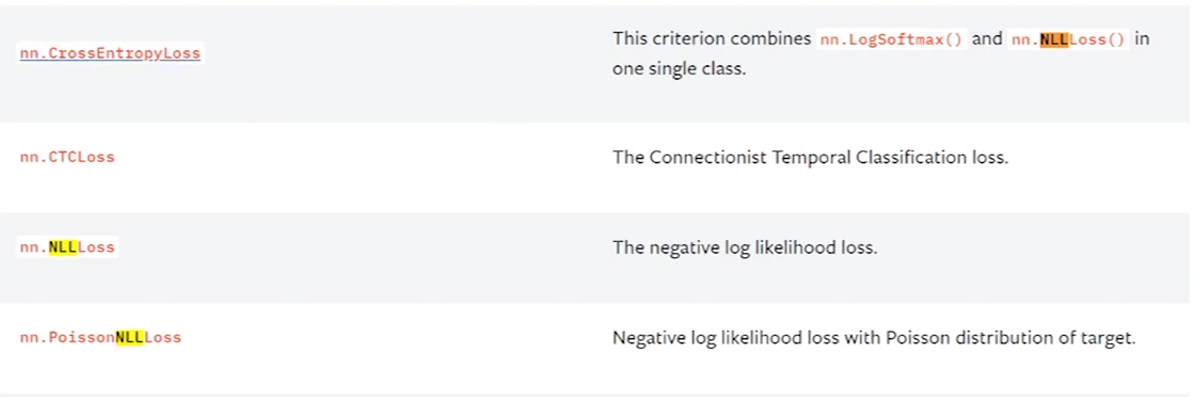

In [30]:
 criterion = nn.NLLLoss().to(device)
 optimizer = torch.optim.Adam(model.parameters(), lr=args['lr'], weight_decay=args['regularizacao'])

In [31]:
def forward(X, Y, etapa, epoca):
  if etapa == 'Treino': model.train()
  else: model.eval()
  acuracia = 0.
  loss_epoca = []

  for k, (dado, rotulo) in enumerate(zip(X, Y)):
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    saida = model(dado) # saida = B x C = 1 x 18
    loss = criterion(saida, rotulo)
    loss_epoca.append(loss.detach().cpu().numpy())

    _, pred = torch.max(saida, axis=-1)
    acuracia += 1 if pred[0].item() == rotulo[0].item() else 0

    if etapa == 'Treino':
      # Otimização
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  loss_epoca = np.asarray(loss_epoca).ravel()
  acuracia   = acuracia/float(len(loss_epoca))
  print('\n','*'*15 + etapa + '*'*15 )
  print('Epoca: {:}, Loss: {:.4f} +/- {:.4f}, Acurácia: {:.4f}'.format(epoca, loss_epoca.mean(),
                                                                        loss_epoca.std(),
                                                                        acuracia*100
                                                                       ))
  return loss_epoca.mean(), acuracia

In [32]:
loss_treino, loss_test = [], []
acc_treino, acc_test = [], []

dados_test, rotulos_test = sample_batch(size=num_amostras)
for epoch in range(100):

  dados_tns, rotulos_tns = sample_batch()

  loss, acc = forward(dados_tns, rotulos_tns, 'Treino', epoch)
  loss_treino.append(loss)
  acc_treino.append(acc)

  loss, acc = forward(dados_test, rotulos_test, 'Teste', epoch)
  loss_test.append(loss)
  acc_test.append(acc)


Distribuição de rótulos no batch: Counter({'Arabic': 74, 'Chinese': 74, 'Czech': 74, 'Dutch': 74, 'English': 74, 'French': 74, 'German': 74, 'Greek': 74, 'Irish': 74, 'Italian': 74, 'Japanese': 74, 'Korean': 74, 'Polish': 74, 'Portuguese': 74, 'Russian': 74, 'Scottish': 74, 'Spanish': 74, 'Vietnamese': 74})
Distribuição de rótulos no batch: Counter({'Arabic': 74, 'Chinese': 74, 'Czech': 74, 'Dutch': 74, 'English': 74, 'French': 74, 'German': 74, 'Greek': 74, 'Irish': 74, 'Italian': 74, 'Japanese': 74, 'Korean': 74, 'Polish': 74, 'Portuguese': 74, 'Russian': 74, 'Scottish': 74, 'Spanish': 74, 'Vietnamese': 74})


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)



 ***************Treino***************
Epoca: 0, Loss: 2.6180 +/- 0.7905, Acurácia: 15.7658

 ***************Teste***************
Epoca: 0, Loss: 3.0955 +/- 0.6937, Acurácia: 6.6066
Distribuição de rótulos no batch: Counter({'Arabic': 74, 'Chinese': 74, 'Czech': 74, 'Dutch': 74, 'English': 74, 'French': 74, 'German': 74, 'Greek': 74, 'Irish': 74, 'Italian': 74, 'Japanese': 74, 'Korean': 74, 'Polish': 74, 'Portuguese': 74, 'Russian': 74, 'Scottish': 74, 'Spanish': 74, 'Vietnamese': 74})

 ***************Treino***************
Epoca: 1, Loss: 2.5412 +/- 0.7760, Acurácia: 14.9399

 ***************Teste***************
Epoca: 1, Loss: 3.6190 +/- 1.3491, Acurácia: 8.3333
Distribuição de rótulos no batch: Counter({'Arabic': 74, 'Chinese': 74, 'Czech': 74, 'Dutch': 74, 'English': 74, 'French': 74, 'German': 74, 'Greek': 74, 'Irish': 74, 'Italian': 74, 'Japanese': 74, 'Korean': 74, 'Polish': 74, 'Portuguese': 74, 'Russian': 74, 'Scottish': 74, 'Spanish': 74, 'Vietnamese': 74})

 ***************T

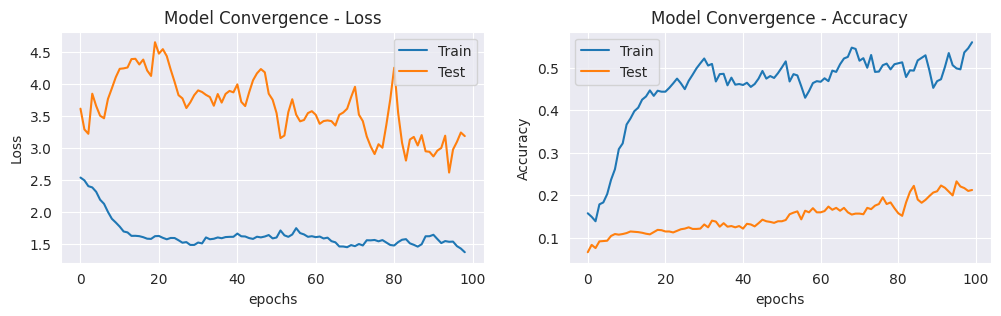

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))

ax1.plot(loss_treino[1:], label='Train')
ax1.plot(loss_test[1:], label='Test')
ax1.set_title('Model Convergence - Loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(acc_treino, label='Train')
ax2.plot(acc_test, label='Test')
ax2.set_title('Model Convergence - Accuracy')
ax2.set_xlabel('epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

In [34]:
def predict(nome):
  model.eval()

  tns = torch.zeros( len(nome), len(dicionario) )
  for k, letra in enumerate(nome):
    idx = dicionario.find(letra)
    tns[k, idx] = 1
  tns = tns.to(args['device'])

  saida = model(tns)
  #topk pega top 3 predições ao chamar modelo passando o tensor
  topv, topi = saida.data.topk(3, 1, True)

  print(nome)
  for value, index in zip(topv[0], topi[0]):
    print('(%.2f) %s' % (value, categorias[index]))
  print('\n')

predict('Mota')
predict('Kamikaze')
predict('Suarez')

Mota
(-1.09) Japanese
(-1.49) Portuguese
(-2.36) Spanish


Kamikaze
(-0.55) Spanish
(-1.09) Scottish
(-4.03) Arabic


Suarez
(-0.88) Spanish
(-2.18) Portuguese
(-2.24) Scottish




/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


## Passos importantes

* O que é a memória de sequência.

A memória humana ao processar sequências não memoriza elementos individuais, mas, sim, o padrão que relaciona os elementos em uma determinada ordem. Redes neurais recorrentes (RNN) foram projetadas com o mesmo propósito.

* Tipos de dados sequenciais

Quaisquer conjuntos de dados onde cada amostra pode ser dividida em eventos individuais, sendo a ordem dos eventos um fator relevante. Por exemplo: texto, voz, partitura musical, vídeo etc.

* Limitações do Multi-Layer Perceptron (MLP)

Apesar de ser possível aplicar o MLP no processamento de sequências, ele apresenta uma série de limitações em grande parte relacionadas à sua incapacidade de memorizar acontecimentos passados.

* Motivação para o uso de Redes Neurais Recorrentes

As limitações do MLP levaram à proposição de uma nova arquitetura, a RNN, capaz de guardar uma memória interna de acontecimentos passados, levando-os em consideração ao processar novos eventos.

* O fluxo de dados em uma célula recorrente.

A célula recorrente básica possui muitas similaridades com um Multi-Layer Perceptron, com a vantagem extra de uma memória interna que permite acumular contexto dos elementos de uma sequência em um processamento iterativo.

* RNNCell no PyTorch

O pacote nn de redes neurais do PyTorch fornece uma célula recorrente simples, que nos permite implementar explicitamente o fluxo iterativo de uma sequência.

* A memória interna (hidden state)

A memória interna de uma RNN básica nada mais é do que um vetor do mesmo tamanho que a quantidade de neurônios da camada. Ela recebe esse nome por ser retroalimentada para a camada, acumulando contexto da sequência.

* Construção de Vocabulário e Representação One Hot

No contexto de processamento de texto, aprendemos a representar strings como tensores, modelando uma sequência de caracteres a partir de um vocabulário pré-definido.

* Classificação de nomes com uma Char-RNN

Nossa primeira prática! Aqui você viu como usar a RNNCell processando nomes próprios como uma sequência de caracteres para predizer a sua nacionalidade.